# Fibonacci: recursion, sequences, and repeated work

Compare the direct recurrence, an iterative loop, and recursive memoization. This notebook derives their growth, counts work, probes depth, and compares measurements with theoretical shapes. The timed experiment targets 10 seconds so the full Week 09 suite stays under two minutes.

Use F(0) = 0, F(1) = 1, and F(n) = F(n - 1) + F(n - 2).

In [1]:
def fib_recursive(n):
    if n < 0:
        raise ValueError("n must be nonnegative")
    if n < 2:
        return n
    return fib_recursive(n - 1) + fib_recursive(n - 2)


def fib_loop(n):
    if n < 0:
        raise ValueError("n must be nonnegative")
    previous, current = 0, 1
    for _ in range(n):
        previous, current = current, previous + current
    return previous


def fib_memoized(n, cache=None):
    if n < 0:
        raise ValueError("n must be nonnegative")
    if cache is None:
        cache = {0: 0, 1: 1}
    if n not in cache:
        cache[n] = fib_memoized(n - 1, cache) + fib_memoized(n - 2, cache)
    return cache[n]

## Check small values

Print named columns so the sequence and the three implementations are easy to compare.

In [2]:
fibonacci_examples = []
for n in range(11):
    row = {
        "n": n,
        "plain recursion": fib_recursive(n),
        "loop": fib_loop(n),
        "memoized": fib_memoized(n),
    }
    fibonacci_examples.append(row)

for row in fibonacci_examples:
    print(row)

{'n': 0, 'plain recursion': 0, 'loop': 0, 'memoized': 0}
{'n': 1, 'plain recursion': 1, 'loop': 1, 'memoized': 1}
{'n': 2, 'plain recursion': 1, 'loop': 1, 'memoized': 1}
{'n': 3, 'plain recursion': 2, 'loop': 2, 'memoized': 2}
{'n': 4, 'plain recursion': 3, 'loop': 3, 'memoized': 3}
{'n': 5, 'plain recursion': 5, 'loop': 5, 'memoized': 5}
{'n': 6, 'plain recursion': 8, 'loop': 8, 'memoized': 8}
{'n': 7, 'plain recursion': 13, 'loop': 13, 'memoized': 13}
{'n': 8, 'plain recursion': 21, 'loop': 21, 'memoized': 21}
{'n': 9, 'plain recursion': 34, 'loop': 34, 'memoized': 34}
{'n': 10, 'plain recursion': 55, 'loop': 55, 'memoized': 55}


## Derive the growth of each implementation

### Plain recursion: exponential time

Let C(n) count calls, including the current call. C(0) = C(1) = 1. For n >= 2, C(n) = C(n - 1) + C(n - 2) + 1: two recursive branches plus this call. The sequence begins 1, 1, 3, 5, 9, 15, ... . Solving gives C(n) = 2F(n + 1) - 1. Since F(n) grows proportionally to phi^n, where phi = (1 + sqrt(5))/2, plain recursion takes Theta(phi^n) calls and O(phi^n) time. Maximum active call depth is O(n), even though total work is exponential.

### Iterative loop: linear time, constant extra space

The loop advances exactly n times and performs one addition per iteration. Thus T_loop(n) = c*n + d for constants c,d, which is Theta(n), hence O(n). It stores only two values, so extra space is Theta(1).

### Memoized recursion: linear work, linear storage

With {0: 0, 1: 1} cached, each new value F(2) through F(n) is computed once: n - 1 additions for n >= 1. The total lookup call count is 2n - 1 for n >= 1, so time is Theta(n), or O(n), and the cache uses Theta(n) space. Its recursive chain still has depth n.

These are unit-cost arithmetic bounds. Fibonacci values have Theta(n) bits, so additions get more expensive as n grows. The textbook O(n) statement abstracts away growing integer size; counts and timings make that model visible.

## Count calls and additions

Counters record the selected operations, not the bookkeeping used to maintain the counters. Instrumented functions are not used for timing because instrumentation changes runtime.

In [3]:
def fib_plain_counted(n):
    calls, additions = [0], [0]
    def visit(k):
        calls[0] += 1
        if k < 2:
            return k
        additions[0] += 1
        return visit(k - 1) + visit(k - 2)
    answer = visit(n)
    return answer, calls[0], additions[0]


def fib_memo_counted(n):
    calls, additions = [0], [0]
    cache = {0: 0, 1: 1}
    def visit(k):
        calls[0] += 1
        if k not in cache:
            additions[0] += 1
            cache[k] = visit(k - 1) + visit(k - 2)
        return cache[k]
    answer = visit(n)
    return answer, calls[0], additions[0], len(cache)


count_sizes = tuple(range(13))
fibonacci_count_rows = []
for n in count_sizes:
    plain_value, plain_calls, plain_additions = fib_plain_counted(n)
    memo_value, memo_calls, memo_additions, cached_values = fib_memo_counted(n)
    if plain_value != memo_value or memo_value != fib_loop(n):
        raise AssertionError(f"Methods disagree at n={n}")
    row = {
        "n": n,
        "plain calls": plain_calls,
        "plain additions": plain_additions,
        "memo calls": memo_calls,
        "memo additions": memo_additions,
        "cached values": cached_values,
        "loop additions": n,
    }
    fibonacci_count_rows.append(row)

for row in fibonacci_count_rows:
    print(row)

{'n': 0, 'plain calls': 1, 'plain additions': 0, 'memo calls': 1, 'memo additions': 0, 'cached values': 2, 'loop additions': 0}
{'n': 1, 'plain calls': 1, 'plain additions': 0, 'memo calls': 1, 'memo additions': 0, 'cached values': 2, 'loop additions': 1}
{'n': 2, 'plain calls': 3, 'plain additions': 1, 'memo calls': 3, 'memo additions': 1, 'cached values': 3, 'loop additions': 2}
{'n': 3, 'plain calls': 5, 'plain additions': 2, 'memo calls': 5, 'memo additions': 2, 'cached values': 4, 'loop additions': 3}
{'n': 4, 'plain calls': 9, 'plain additions': 4, 'memo calls': 7, 'memo additions': 3, 'cached values': 5, 'loop additions': 4}
{'n': 5, 'plain calls': 15, 'plain additions': 7, 'memo calls': 9, 'memo additions': 4, 'cached values': 6, 'loop additions': 5}
{'n': 6, 'plain calls': 25, 'plain additions': 12, 'memo calls': 11, 'memo additions': 5, 'cached values': 7, 'loop additions': 6}
{'n': 7, 'plain calls': 41, 'plain additions': 20, 'memo calls': 13, 'memo additions': 6, 'cached va

Plain recursion follows an exponential call sequence; memoized calls/additions and loop additions grow linearly. The recurrence is the same, but the execution tree changes dramatically.

## Probe recursion depth

Memoization removes repeated work but still descends one call per n. Set this kernel's recursion limit to 5,000, verify n = 4,900, and catch the expected RecursionError above the limit. Do not run naive recursion at large n: its exponential work would be excessive.

In [4]:
import sys

previous_recursion_limit = sys.getrecursionlimit()
sys.setrecursionlimit(5_000)
memoized_depth = 4_900
deep_fibonacci = fib_memoized(memoized_depth)
print(f"Previous limit: {previous_recursion_limit:,}; current limit: {sys.getrecursionlimit():,}.")
print(f"Memoized F({memoized_depth:,}) completed; result has {len(str(deep_fibonacci)):,} digits.")
try:
    fib_memoized(5_100)
except RecursionError as error:
    print(f"A deeper request safely reaches {type(error).__name__}.")

Previous limit: 5,000; current limit: 5,000.
Memoized F(4,900) completed; result has 1,024 digits.
A deeper request safely reaches RecursionError.


## Benchmark the methods

Naive recursion is measured only through n = 30. The loop and memoized versions are measured through n = 4,000. Sweeps run for 10 seconds, with a 25-second stop; medians reduce brief background-noise effects. Integer sizes also grow with n, so timings include larger additions as well as the unit-cost operation count.

In [5]:
from statistics import median
from time import perf_counter

naive_sizes = (5, 10, 15, 20, 25, 30)
linear_sizes = (25, 100, 400, 1_000, 2_000, 4_000)
timings = {
    "naive": {n: [] for n in naive_sizes},
    "loop": {n: [] for n in linear_sizes},
    "memoized": {n: [] for n in linear_sizes},
}
target_seconds, maximum_seconds = 10.0, 25.0
benchmark_start, sweeps = perf_counter(), 0
while True:
    elapsed = perf_counter() - benchmark_start
    if elapsed >= maximum_seconds or elapsed >= target_seconds:
        break
    for n in naive_sizes:
        start = perf_counter()
        fib_recursive(n)
        timings["naive"][n].append(perf_counter() - start)
    for n in linear_sizes:
        start = perf_counter()
        fib_loop(n)
        timings["loop"][n].append(perf_counter() - start)
        start = perf_counter()
        fib_memoized(n)
        timings["memoized"][n].append(perf_counter() - start)
    sweeps += 1
benchmark_seconds = perf_counter() - benchmark_start
print(f"Completed {sweeps} sweeps in {benchmark_seconds:.1f} seconds.")
for n in naive_sizes:
    print({"n": n, "method": "plain recursion", "seconds": median(timings["naive"][n])})
for n in linear_sizes:
    print({"n": n, "method": "loop", "seconds": median(timings["loop"][n])})
    print({"n": n, "method": "memoized recursion", "seconds": median(timings["memoized"][n])})

Completed 54 sweeps in 10.1 seconds.
{'n': 5, 'method': 'plain recursion', 'seconds': 1.8998980522155762e-06}
{'n': 10, 'method': 'plain recursion', 'seconds': 1.0299962013959885e-05}
{'n': 15, 'method': 'plain recursion', 'seconds': 0.00011030002497136593}
{'n': 20, 'method': 'plain recursion', 'seconds': 0.0012519998708739877}
{'n': 25, 'method': 'plain recursion', 'seconds': 0.014603949966840446}
{'n': 30, 'method': 'plain recursion', 'seconds': 0.165343250031583}
{'n': 25, 'method': 'loop', 'seconds': 4.90015372633934e-06}
{'n': 25, 'method': 'memoized recursion', 'seconds': 1.719989813864231e-05}
{'n': 100, 'method': 'loop', 'seconds': 4.499917849898338e-06}
{'n': 100, 'method': 'memoized recursion', 'seconds': 2.5900080800056458e-05}
{'n': 400, 'method': 'loop', 'seconds': 1.7300015315413475e-05}
{'n': 400, 'method': 'memoized recursion', 'seconds': 0.00016644992865622044}
{'n': 1000, 'method': 'loop', 'seconds': 4.8099784180521965e-05}
{'n': 1000, 'method': 'memoized recursion',

## Graph measured runtime and counted work

Dashed lines show scaled growth references: phi^n for plain recursion, n for loop/memoized work. They communicate shape, not predicted seconds. Log axes let us compare exponential and linear growth across different input ranges.

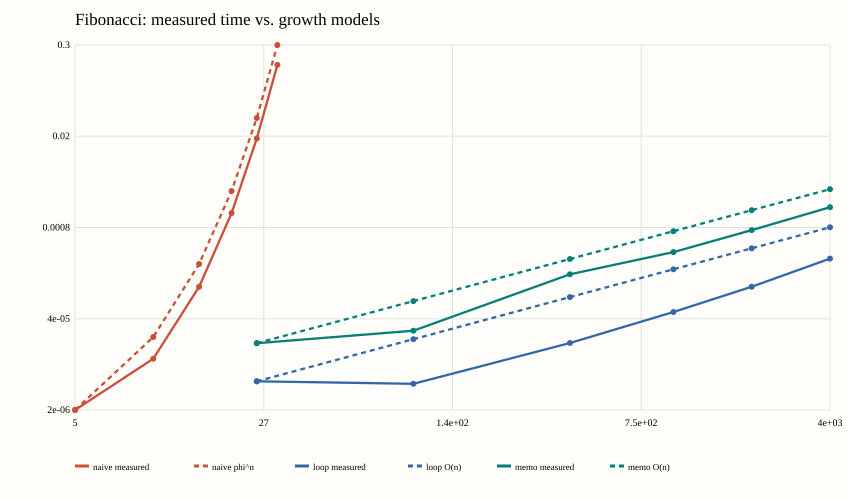

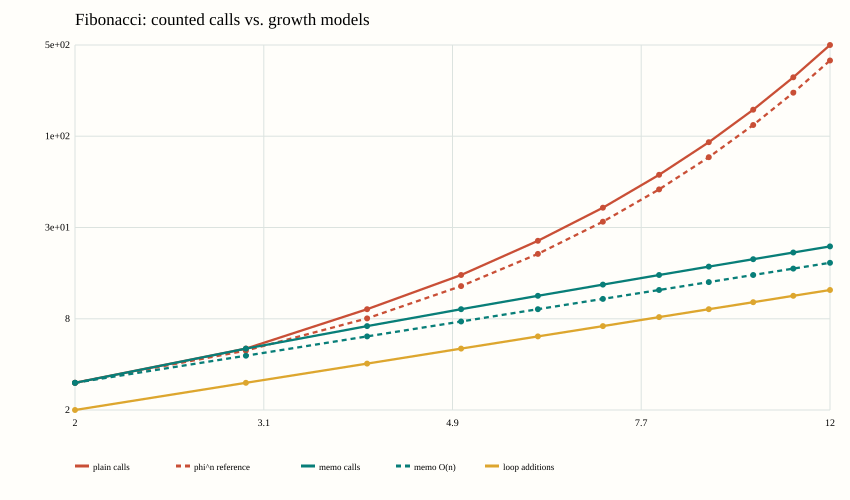

In [6]:
import math
from IPython.display import SVG, display

def log_chart(title, series):
    width, height = 850, 500
    left, right, top, bottom = 75, 20, 45, 90
    xs = [x for item in series for x in item["x"]]
    ys = [y for item in series for y in item["y"] if y > 0]
    x0, x1 = math.log10(min(xs)), math.log10(max(xs))
    y0, y1 = math.log10(min(ys)), math.log10(max(ys))
    pw, ph = width - left - right, height - top - bottom
    def px(x): return left + (math.log10(x) - x0) / (x1 - x0) * pw
    def py(y): return top + ph - (math.log10(y) - y0) / (y1 - y0) * ph
    parts = [f'<svg xmlns="http://www.w3.org/2000/svg" viewBox="0 0 {width} {height}">']
    parts.append(f'<rect width="100%" height="100%" fill="#fffefa"/><text x="{left}" y="25" font-size="17">{title}</text>')
    for i in range(5):
        f = i / 4
        x, y = 10 ** (x0 + f * (x1 - x0)), 10 ** (y0 + f * (y1 - y0))
        xp, yp = left + f * pw, top + ph - f * ph
        parts.append(f'<line x1="{xp:.1f}" y1="{top}" x2="{xp:.1f}" y2="{top + ph}" stroke="#dce3df"/><line x1="{left}" y1="{yp:.1f}" x2="{left + pw}" y2="{yp:.1f}" stroke="#dce3df"/>')
        parts.append(f'<text x="{xp:.1f}" y="{top + ph + 16}" text-anchor="middle" font-size="10">{x:.2g}</text><text x="{left - 5}" y="{yp + 3:.1f}" text-anchor="end" font-size="10">{y:.1g}</text>')
    lx, ly = left, height - 34
    for item in series:
        color, dash, label = item["color"], item.get("dash", "none"), item["label"]
        pts = " ".join(f"{px(x):.1f},{py(y):.1f}" for x, y in zip(item["x"], item["y"]) if y > 0)
        parts.append(f'<polyline points="{pts}" fill="none" stroke="{color}" stroke-width="2.3" stroke-dasharray="{dash}"/>')
        for x, y in zip(item["x"], item["y"]):
            if y > 0:
                parts.append(f'<circle cx="{px(x):.1f}" cy="{py(y):.1f}" r="3" fill="{color}"/>')
        if lx + len(label) * 6 + 35 > width - right:
            lx, ly = left, ly + 16
        parts.append(f'<line x1="{lx}" y1="{ly}" x2="{lx + 14}" y2="{ly}" stroke="{color}" stroke-width="3" stroke-dasharray="{dash}"/><text x="{lx + 18}" y="{ly + 4}" font-size="9">{label}</text>')
        lx += len(label) * 6 + 35
    parts.append("</svg>")
    return SVG("".join(parts))

phi = (1 + math.sqrt(5)) / 2
naive_times = [median(timings["naive"][n]) for n in naive_sizes]
loop_times = [median(timings["loop"][n]) for n in linear_sizes]
memo_times = [median(timings["memoized"][n]) for n in linear_sizes]
runtime_series = [
    {"label": "naive measured", "x": list(naive_sizes), "y": naive_times, "color": "#c94f36"},
    {"label": "naive phi^n", "x": list(naive_sizes), "y": [naive_times[0] * phi ** (n - naive_sizes[0]) for n in naive_sizes], "color": "#c94f36", "dash": "5 4"},
    {"label": "loop measured", "x": list(linear_sizes), "y": loop_times, "color": "#3567a6"},
    {"label": "loop O(n)", "x": list(linear_sizes), "y": [loop_times[0] * n / linear_sizes[0] for n in linear_sizes], "color": "#3567a6", "dash": "5 4"},
    {"label": "memo measured", "x": list(linear_sizes), "y": memo_times, "color": "#087e78"},
    {"label": "memo O(n)", "x": list(linear_sizes), "y": [memo_times[0] * n / linear_sizes[0] for n in linear_sizes], "color": "#087e78", "dash": "5 4"},
]
display(log_chart("Fibonacci: measured time vs. growth models", runtime_series))

count_n = list(count_sizes[2:])
plain_calls = [row["plain calls"] for row in fibonacci_count_rows[2:]]
memo_calls = [row["memo calls"] for row in fibonacci_count_rows[2:]]
count_series = [
    {"label": "plain calls", "x": count_n, "y": plain_calls, "color": "#c94f36"},
    {"label": "phi^n reference", "x": count_n, "y": [plain_calls[0] * phi ** (n - count_n[0]) for n in count_n], "color": "#c94f36", "dash": "5 4"},
    {"label": "memo calls", "x": count_n, "y": memo_calls, "color": "#087e78"},
    {"label": "memo O(n)", "x": count_n, "y": [memo_calls[0] * n / count_n[0] for n in count_n], "color": "#087e78", "dash": "5 4"},
    {"label": "loop additions", "x": count_n, "y": count_n, "color": "#dda62e"},
]
display(log_chart("Fibonacci: counted calls vs. growth models", count_series))

## What the comparison tells us

Plain evaluation unfolds a recurrence into a branching tree with overlapping subproblems. Memoization stores prior answers; iteration reuses two values without a call stack. Count graphs follow the derived sequences, while runtime includes call overhead, cache lookup, and growing integers. Big O predicts which approach scales; measurements show constants and representation costs in this Python runtime.

Discuss: which repeated call is visible in the tree for F(5)? Why does memoization help? What does O(n) hide about increasing value size? Why can memoized recursion still hit a depth limit?